# Task 5: deploy one ADK agent

## Goal

Create one Google ADK agent, deploy it to Agent Platform, and prove that the
deployed agent answers a remote query.

## Checklist

- [x] Create an agent with Google ADK.
- [x] Test the same agent locally.
- [x] Deploy the agent to Agent Platform.
- [x] Test the deployed agent in a fresh managed session.
- [x] Save the resource name and remote response.
- [x] Show the running agent in the Agent Platform UI.


## 1. Install the two required packages

The notebook pins the same ADK and Vertex AI versions in the notebook and the
deployed runtime.


In [1]:
import importlib.metadata
import subprocess
import sys


EXPECTED_VERSIONS = {
    "google-cloud-aiplatform": "1.164.0",
    "google-adk": "1.39.0",
}

installed_versions = {
    package: importlib.metadata.version(package)
    for package in EXPECTED_VERSIONS
}
if installed_versions != EXPECTED_VERSIONS:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "google-cloud-aiplatform[agent_engines,adk]==1.164.0",
            "google-adk==1.39.0",
        ],
        check=True,
    )
    installed_versions = {
        package: importlib.metadata.version(package)
        for package in EXPECTED_VERSIONS
    }

assert installed_versions == EXPECTED_VERSIONS
print(installed_versions)


{'google-cloud-aiplatform': '1.164.0', 'google-adk': '1.39.0'}


## 2. Check the Google Cloud project

The notebook uses Application Default Credentials. It stops before deployment
if either credential source points to another project.


In [2]:
from __future__ import annotations

import json
import os
import subprocess
import uuid
from typing import Any

import google.auth
import vertexai
from google.adk.agents import Agent
from vertexai import agent_engines


EXPECTED_PROJECT = "qwiklabs-gcp-02-66b2cfb8579b"
LOCATION = "us-central1"
MODEL_LOCATION = "global"
MODEL = "gemini-2.5-flash"


def run_gcloud(
    arguments: list[str], timeout: int = 60
) -> subprocess.CompletedProcess[str]:
    """Run a bounded gcloud command without printing credentials."""
    return subprocess.run(
        ["gcloud", *arguments],
        check=False,
        capture_output=True,
        text=True,
        timeout=timeout,
    )


project_result = run_gcloud(["config", "get-value", "project"])
detected_project = project_result.stdout.strip()
_, adc_project = google.auth.default()
observed_projects = {
    value for value in (detected_project, adc_project) if value
}

preflight = {
    "expected_project": EXPECTED_PROJECT,
    "gcloud_project": detected_project,
    "adc_project": adc_project,
    "deployment_location": LOCATION,
    "model_location": MODEL_LOCATION,
    "model": MODEL,
}
print(json.dumps(preflight, indent=2))

if observed_projects != {EXPECTED_PROJECT}:
    raise RuntimeError(
        "Project mismatch: expected "
        f"{EXPECTED_PROJECT}, observed {observed_projects}"
    )

os.environ["GOOGLE_CLOUD_PROJECT"] = EXPECTED_PROJECT
os.environ["GOOGLE_CLOUD_LOCATION"] = MODEL_LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "TRUE"


{
  "expected_project": "qwiklabs-gcp-02-66b2cfb8579b",
  "gcloud_project": "qwiklabs-gcp-02-66b2cfb8579b",
  "adc_project": "qwiklabs-gcp-02-66b2cfb8579b",
  "deployment_location": "us-central1",
  "model_location": "global",
  "model": "gemini-2.5-flash"
}


## 3. Create one ADK agent

The shortest complete architecture has one agent. The same `AdkApp` runs
locally and on Agent Platform.

```mermaid
flowchart LR
    U[User] --> A[One ADK agent]
    A --> L[Local test]
    A --> P[Agent Platform deployment]
    P --> R[Remote test]
```


In [3]:
APP_NAME = "task5_simple_adk_agent"

root_agent = Agent(
    name="task5_agent",
    model=MODEL,
    description="A small agent used to prove Agent Platform deployment.",
    instruction=(
        "Answer the user's question accurately in one short paragraph. "
        "If the request is unclear, ask one concise follow-up question."
    ),
)

adk_app = agent_engines.AdkApp(
    agent=root_agent,
    app_name=APP_NAME,
)

print(
    json.dumps(
        {
            "framework": "google-adk",
            "agent_name": root_agent.name,
            "model": root_agent.model,
            "app_name": APP_NAME,
        },
        indent=2,
    )
)


{
  "framework": "google-adk",
  "agent_name": "task5_agent",
  "model": "gemini-2.5-flash",
  "app_name": "task5_simple_adk_agent"
}


## 4. Test locally

This smoke test runs the exact `AdkApp` that the next step deploys.


In [4]:
def event_text(event: dict[str, Any]) -> str:
    """Return the text in one serialized ADK event."""
    parts = event.get("content", {}).get("parts", [])
    return " ".join(
        part.get("text", "")
        for part in parts
        if isinstance(part, dict) and part.get("text")
    ).strip()


def final_response(events: list[dict[str, Any]]) -> str:
    """Return the last nonempty response from an ADK event list."""
    return next(
        (event_text(event) for event in reversed(events) if event_text(event)),
        "",
    )


local_user_id = f"task5-local-{uuid.uuid4().hex[:12]}"
local_session = await adk_app.async_create_session(user_id=local_user_id)
local_events: list[dict[str, Any]] = []
async for event in adk_app.async_stream_query(
    user_id=local_user_id,
    session_id=local_session["id"],
    message="Explain why the sky appears blue in one sentence.",
):
    local_events.append(event)

local_answer = final_response(local_events)
assert local_answer
print(
    json.dumps(
        {
            "session_id": local_session["id"],
            "event_count": len(local_events),
            "response": local_answer,
        },
        indent=2,
    )
)


Direct use of automatic function calling (AFC) in AsyncModels.generate_content is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message. Similarly, direct use of AFC in AsyncModels.generate_content_stream is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message_stream.


{
  "session_id": "59dd370d-b4e4-4174-bb19-553d9063f067",
  "event_count": 1,
  "response": "The sky appears blue because sunlight is scattered by the Earth's atmosphere, and blue light is scattered more efficiently than other colors due to its shorter wavelength. The sky appears blue because sunlight is scattered by the Earth's atmosphere, and blue light is scattered more efficiently than other colors due to its shorter wavelength."
}


## 5. Deploy to Agent Platform

The deployment updates the existing Task 5 resource. Reusing it avoids an
extra billable resource and keeps the grader's resource link stable.


In [5]:
STAGING_BUCKET = f"gs://{EXPECTED_PROJECT}-agent-engine-staging"
bucket_check = run_gcloud(["storage", "buckets", "describe", STAGING_BUCKET])
if bucket_check.returncode != 0:
    bucket_create = run_gcloud(
        [
            "storage",
            "buckets",
            "create",
            STAGING_BUCKET,
            f"--project={EXPECTED_PROJECT}",
            f"--location={LOCATION}",
            "--uniform-bucket-level-access",
        ]
    )
    if bucket_create.returncode != 0:
        raise RuntimeError(bucket_create.stderr.strip()[:600])

vertexai.init(
    project=EXPECTED_PROJECT,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

DEPLOYMENT_REQUIREMENTS = [
    "google-cloud-aiplatform[agent_engines,adk]==1.164.0",
    "google-adk==1.39.0",
]
EXISTING_RESOURCE_NAME = (
    "projects/571054353266/locations/us-central1/"
    "reasoningEngines/4093976020686733312"
)
DISPLAY_NAME = "task5-simple-adk-agent"

remote_agent = agent_engines.update(
    EXISTING_RESOURCE_NAME,
    agent_engine=adk_app,
    requirements=DEPLOYMENT_REQUIREMENTS,
    display_name=DISPLAY_NAME,
    description="One ADK agent deployed for the Task 5 grading check.",
)

RESOURCE_NAME = remote_agent.resource_name
assert RESOURCE_NAME == EXISTING_RESOURCE_NAME
print(
    json.dumps(
        {
            "deployment_status": "updated",
            "display_name": DISPLAY_NAME,
            "resource_name": RESOURCE_NAME,
            "runtime_requirements": DEPLOYMENT_REQUIREMENTS,
        },
        indent=2,
    )
)


Identified the following requirements: {'pydantic': '2.13.4', 'cloudpickle': '3.1.2', 'google-cloud-aiplatform': '1.164.0'}
The following requirements are missing: {'pydantic', 'cloudpickle'}
The following requirements are appended: {'pydantic==2.13.4', 'cloudpickle==3.1.2'}
The final list of requirements: ['google-cloud-aiplatform[agent_engines,adk]==1.164.0', 'google-adk==1.39.0', 'pydantic==2.13.4', 'cloudpickle==3.1.2']
Using bucket qwiklabs-gcp-02-66b2cfb8579b-agent-engine-staging
Wrote to gs://qwiklabs-gcp-02-66b2cfb8579b-agent-engine-staging/agent_engine/agent_engine.pkl
Writing to gs://qwiklabs-gcp-02-66b2cfb8579b-agent-engine-staging/agent_engine/requirements.txt
Update Agent Engine backing LRO: projects/571054353266/locations/us-central1/reasoningEngines/4093976020686733312/operations/6285867264000393216
Agent Engine updated. Resource name: projects/571054353266/locations/us-central1/reasoningEngines/4093976020686733312
{
  "deployment_status": "updated",
  "display_name": "t

## 6. Test the deployed agent

This query runs through Agent Platform in a fresh managed session.


In [6]:
remote_user_id = f"task5-remote-{uuid.uuid4().hex[:12]}"
remote_session = await remote_agent.async_create_session(
    user_id=remote_user_id
)
remote_query = "What is one practical benefit of deploying an agent?"
remote_events: list[dict[str, Any]] = []
async for event in remote_agent.async_stream_query(
    user_id=remote_user_id,
    session_id=remote_session["id"],
    message=remote_query,
):
    remote_events.append(event)

remote_answer = final_response(remote_events)
assert remote_answer
print(
    json.dumps(
        {
            "resource_name": RESOURCE_NAME,
            "remote_session_id": remote_session["id"],
            "query": remote_query,
            "event_count": len(remote_events),
            "response": remote_answer,
        },
        indent=2,
    )
)


{
  "resource_name": "projects/571054353266/locations/us-central1/reasoningEngines/4093976020686733312",
  "remote_session_id": "7085304537715572736",
  "query": "What is one practical benefit of deploying an agent?",
  "event_count": 1,
  "response": "One practical benefit of deploying an agent is its ability to automate repetitive tasks, freeing up human resources for more complex and strategic work."
}


## 7. Agent Platform UI evidence

This screenshot shows `task5-simple-adk-agent` answering a query in the Agent Platform Playground. The selected managed session is `6551627981872168960`.

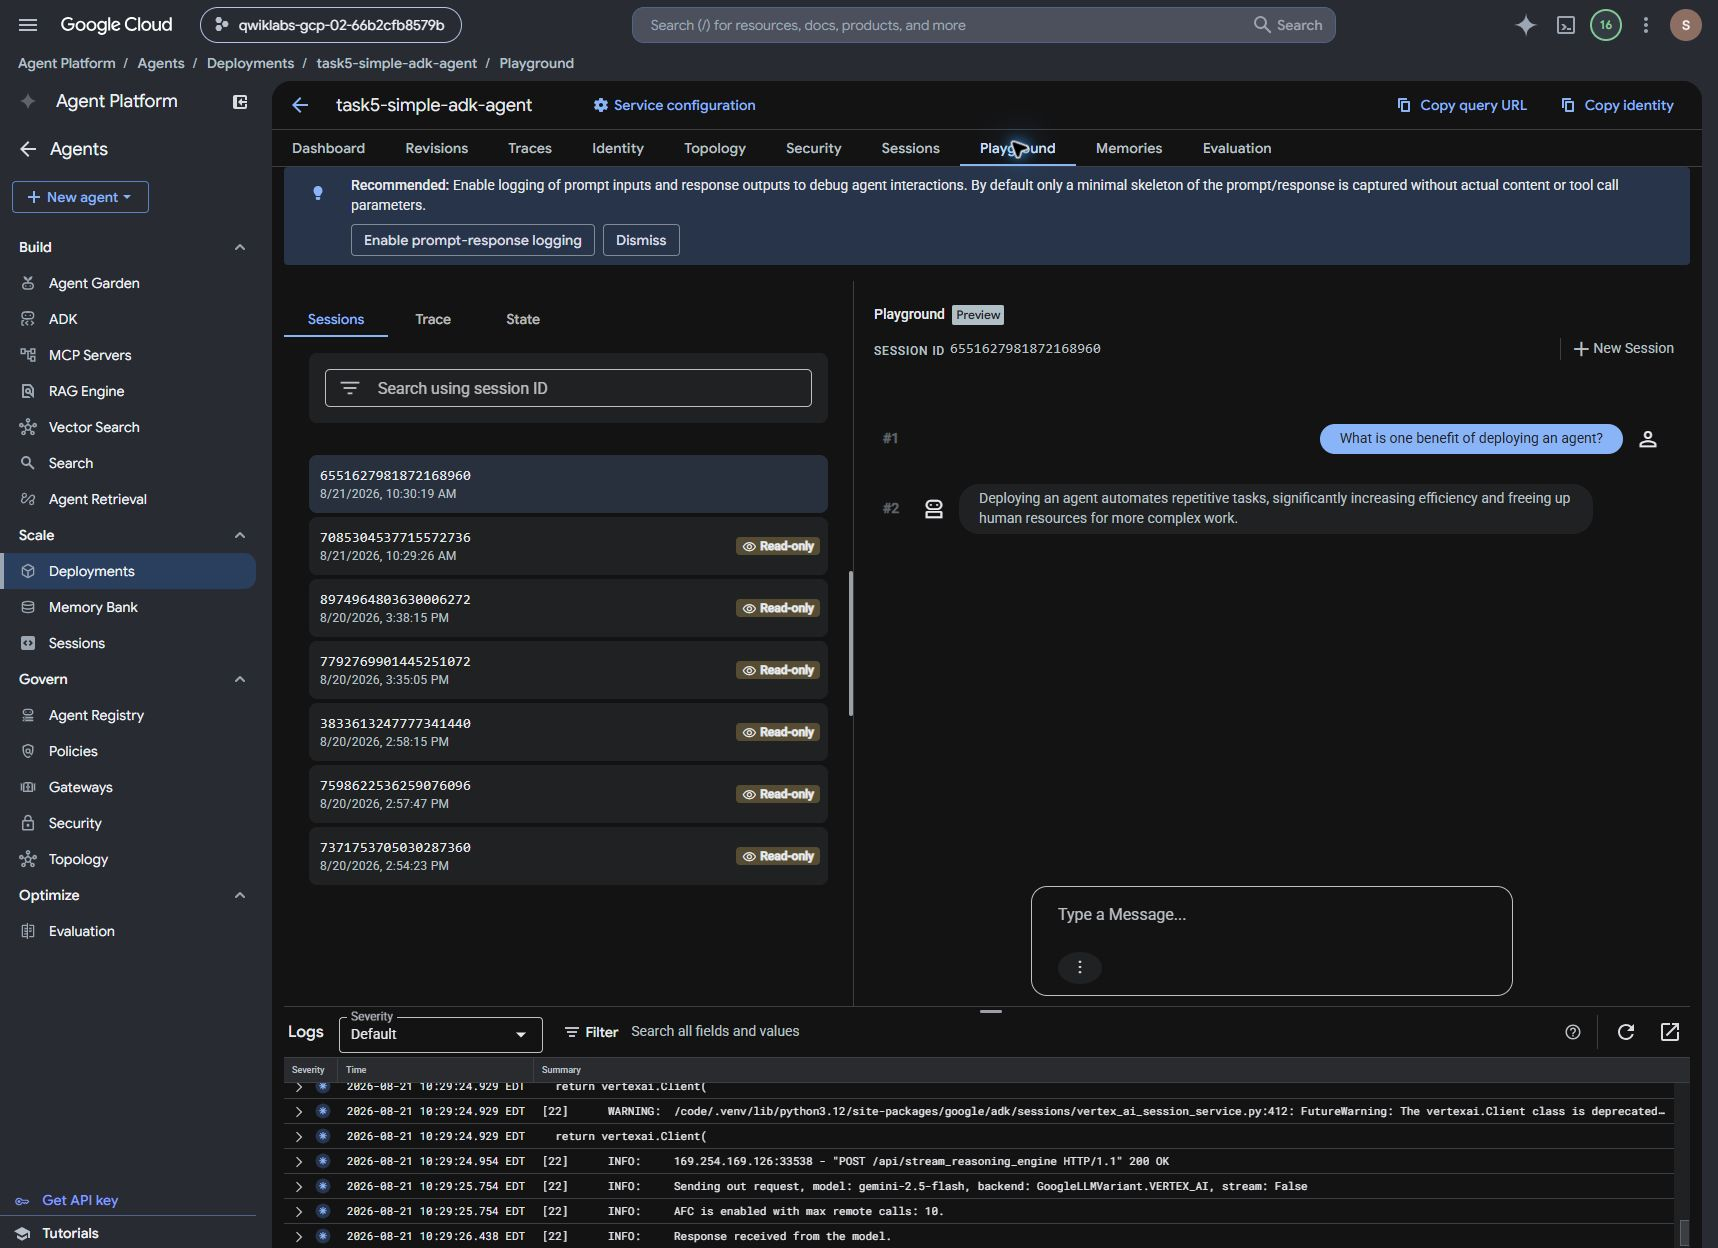


## 8. Keep the resource for grading

The cleanup code is present but disabled. Set `DELETE_AGENT_ENGINE` to `True`
only after grading.


In [7]:
DELETE_AGENT_ENGINE = False

if DELETE_AGENT_ENGINE:
    agent_engines.delete(RESOURCE_NAME, force=True)
    print(f"Deleted Agent Engine: {RESOURCE_NAME}")
else:
    print(
        json.dumps(
            {
                "cleanup_executed": False,
                "resource_retained_for_grading": RESOURCE_NAME,
            },
            indent=2,
        )
    )


{
  "cleanup_executed": false,
  "resource_retained_for_grading": "projects/571054353266/locations/us-central1/reasoningEngines/4093976020686733312"
}


## 9. Grading evidence

These checks map directly to the three Task 5 requirements.


In [8]:
grading_evidence = {
    "adk_agent_created": isinstance(root_agent, Agent),
    "local_test_passed": bool(local_answer),
    "agent_platform_resource_saved": RESOURCE_NAME.startswith("projects/"),
    "remote_test_passed": bool(remote_answer),
    "resource_retained_for_grading": not DELETE_AGENT_ENGINE,
}

assert all(grading_evidence.values()), grading_evidence
print(json.dumps(grading_evidence, indent=2))
print("TASK 5 COMPLETE: ADK agent deployed and tested on Agent Platform.")


{
  "adk_agent_created": true,
  "local_test_passed": true,
  "agent_platform_resource_saved": true,
  "remote_test_passed": true,
  "resource_retained_for_grading": true
}
TASK 5 COMPLETE: ADK agent deployed and tested on Agent Platform.


## References

- [Deploy an ADK agent to Agent Engine](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/deploy)
- [Agent Engine sessions](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/sessions/overview)
